## Toy Regression Problem

### Dependencies

In [ ]:
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Dataset

torch.set_default_dtype(torch.float64)

### Create toy data

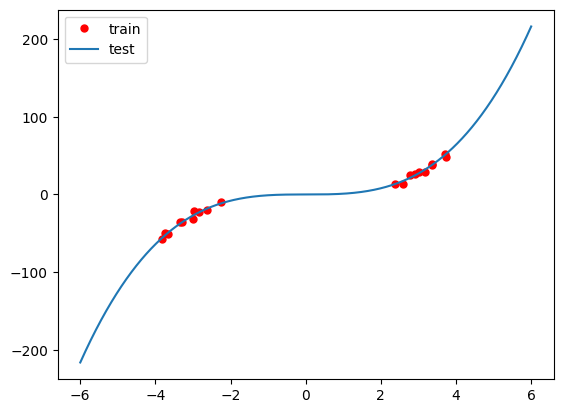

In [2]:
NUM_TRAIN_POINTS = 20
NUM_TEST_POINTS = 10000
std = 3
a1,a2,b1,b2 = -4,-2,2,4
c1,c2 = -6,6
eps = torch.randn((NUM_TRAIN_POINTS),1)*std
train_x = torch.cat((
    torch.rand((int(NUM_TRAIN_POINTS/2),1)) * (a2-a1) + a1,
    torch.rand((int(NUM_TRAIN_POINTS/2),1)) * (b2-b1) + b1
),dim=0)
train_y = torch.pow(train_x,3) + eps


test_x = torch.linspace(c1,c2,NUM_TEST_POINTS).reshape(-1,1)
test_y = torch.pow(test_x,3).reshape(-1,1)

## plot train
plt.plot(train_x.cpu().numpy().reshape(-1),train_y.cpu().numpy().reshape(-1),'ro',markersize=5,label='train')
plt.plot(test_x.cpu().numpy().reshape(-1),test_y.cpu().numpy().reshape(-1),label='test')
plt.legend()
plt.show()

In [3]:
class toy_dataset(Dataset):
    def __init__(self,x,y):
        self.x = x
        self.y = y

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, i):
        return self.x[i], self.y[i]
    
toy_train_loader = DataLoader(toy_dataset(train_x,train_y),NUM_TRAIN_POINTS)
toy_test_loader = DataLoader(toy_dataset(test_x,test_y),NUM_TEST_POINTS)

### Train DNN

Using cpu device


  7%|▋         | 718/10000 [00:00<00:02, 3460.53it/s]

Train loss = 1301.8923


 15%|█▍        | 1459/10000 [00:00<00:02, 3493.01it/s]

Train loss = 84.9389


...

Train loss = 6.9082


 93%|█████████▎| 9276/10000 [00:02<00:00, 3430.58it/s]

Train loss = 6.7533


100%|██████████| 10000/10000 [00:02<00:00, 3452.69it/s]

Done!


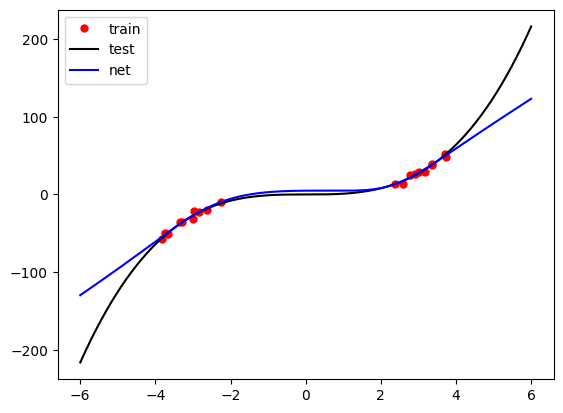

In [4]:
# Get cpu, gpu or mps device for training.
import utils.training


device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

## Set up neural network.
width = 50

class oneLayerMLP(torch.nn.Module):
    def __init__(self, width):
        super().__init__()
        self.output_size = 1
        self.net = torch.nn.Sequential(
            torch.nn.Linear(1, width),
            torch.nn.SiLU(),
            torch.nn.Linear(width, 1)
        )

    def forward(self, x):
        output = self.net(x)
        return output

## MSE Model
map_net = oneLayerMLP(width).to(device)
map_net.apply(utils.training.weights_init_ff)

map_epochs = 10000
map_lr = 0.001
map_wd = 0

mse_loss = torch.nn.MSELoss()
optimizer_MSE = torch.optim.Adam(map_net.parameters(), lr = map_lr, weight_decay=map_wd)
scheduler_MSE = torch.optim.lr_scheduler.PolynomialLR(optimizer_MSE, map_epochs, 0.5)

## Training loop
def train(X, y, model, loss_fn, optimizer, scheduler):
    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    optimizer.zero_grad()
    # Backpropagation
    loss.backward()

    optimizer.step()
    scheduler.step()
    
    return loss.item()

def test(X, y, model, loss_fn):
    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    return loss.item()

train_MSE = True
if train_MSE:
    for t in tqdm(range(map_epochs)):
        train_loss = train(train_x, train_y, map_net, mse_loss, optimizer_MSE, scheduler_MSE)
        if t % (map_epochs / 10) == 0:
            print("Train loss = {:.4f}".format(train_loss))
    print("Done!")

## plot train
plt.plot(train_x.cpu().numpy().reshape(-1),train_y.cpu().numpy().reshape(-1),'ro',markersize=5,label='train')
plt.plot(test_x.cpu().numpy().reshape(-1),test_y.cpu().numpy().reshape(-1),'k',label='test')
plt.plot(test_x.cpu().numpy().reshape(-1), map_net(test_x).detach().cpu().numpy().reshape(-1), 'b', label='net')
plt.legend()
plt.show()

## Posteriors

### DNN-GLM

100%|██████████| 5000/5000 [00:14<00:00, 349.07it/s, mean_sq loss=6.33, mean_grad norm=0.144, gpu_mem=0]


Linear sampling training complete.


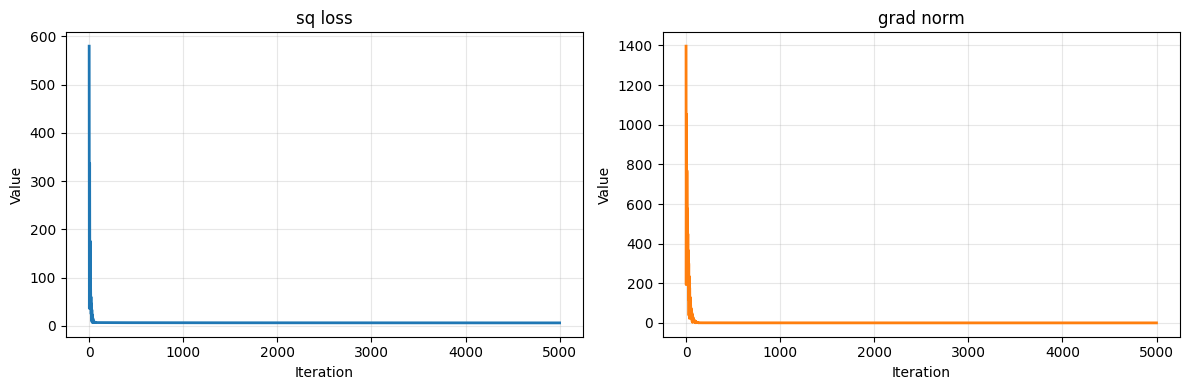

In [12]:
import LinearSampling.Posteriors

train_data = toy_dataset(train_x,train_y)
test_data = toy_dataset(test_x,test_y)

dnn_glm = LinearSampling.Posteriors.Posterior(network=map_net, 
                                              glm_type='DNN',
                                              task='regression', 
                                              precision = 'double')

res = dnn_glm.train(train=train_data, 
                    bs=NUM_TRAIN_POINTS,
                    gamma = 1,
                    S = 10,
                    epochs=5000,
                    lr=1e-3,
                    mu=0.9,
                    verbose=True,
                    plot_loss_dir='metrics/')

dnn_preds = dnn_glm.test(test_data, bs=50)

dnn_mu = dnn_preds.mean(0)
dnn_var = dnn_preds.var(0)

### LL-GLM

100%|██████████| 5000/5000 [00:05<00:00, 873.63it/s, mean_sq loss=6.63, mean_grad norm=0.067, gpu_mem=0] 


Linear sampling training complete.


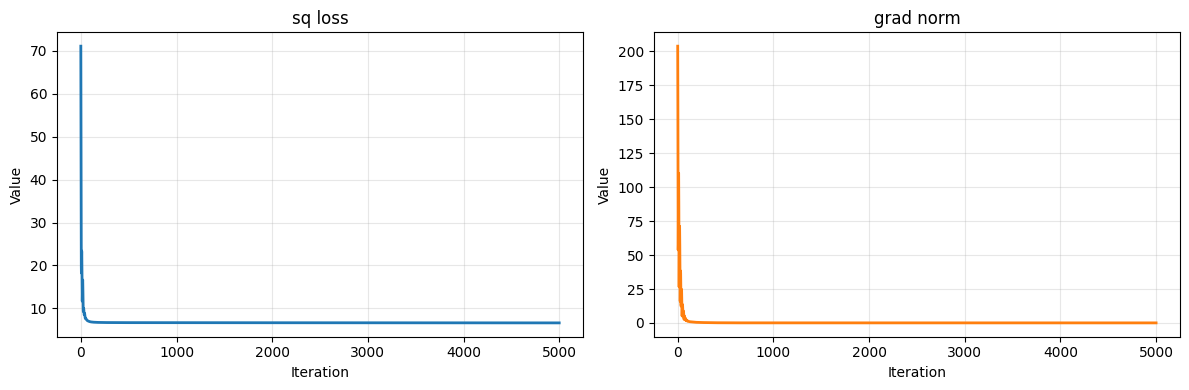

In [ ]:
ll_glm = LinearSampling.Posteriors.Posterior(network=map_net, 
                                              glm_type='LL',
                                              task='regression', 
                                              precision = 'double')

res = ll_glm.train(train=train_data, 
                    bs=NUM_TRAIN_POINTS,
                    gamma = 1,
                    S = 10,
                    epochs=5000,
                    lr=1e-3,
                    mu=0.9,
                    verbose=True,
                    plot_loss_dir='metrics/')

ll_preds = ll_glm.test(test_data, bs=50)

ll_mu = ll_preds.mean(0)
ll_var = ll_preds.var(0)

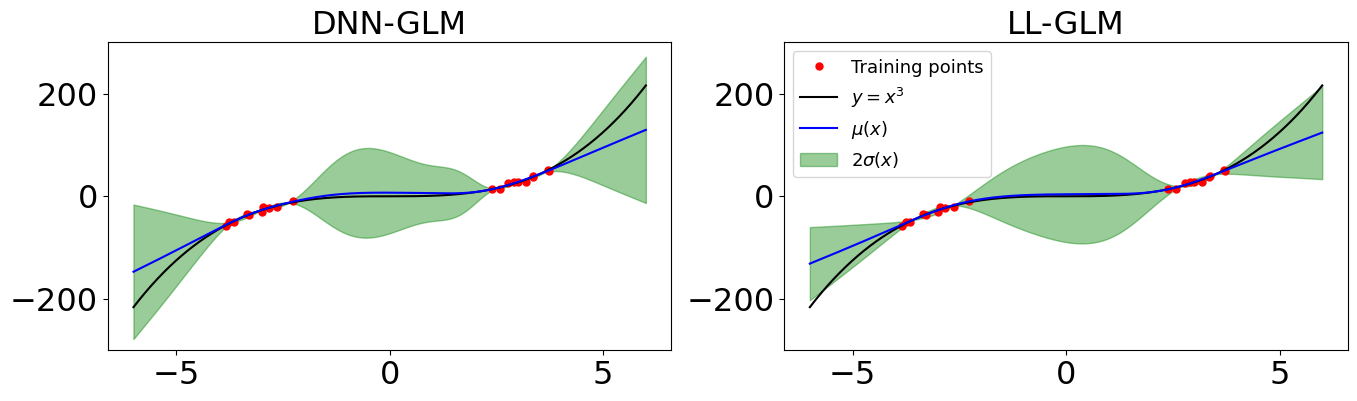

In [9]:
## Plot
def plot_torch(x):
    return x.detach().cpu().numpy().reshape(-1)

def plot_bayes_method(ax,mean,var,title,fs,ms,lw, legend_true=False):
    ax.plot(plot_torch(train_x),plot_torch(train_y),'ro',markersize=ms, label='Training points')
    ax.plot(plot_torch(test_x),plot_torch(test_y),'k',linewidth=lw, label='$y = x^3$')
    ax.plot(plot_torch(test_x),plot_torch(mean),'b',linewidth=lw, label='$\mu(x)$')

    ci = torch.sqrt(var)*2
    y1, y2 = mean - ci, mean + ci

    ax.fill_between(plot_torch(test_x), plot_torch(y1), plot_torch(y2), color='g', alpha=.4, label='$2\sigma(x)$')

    ax.set_title(title, fontsize=fs)
    ax.set_yticks(np.array((-200,0,200)))
    ax.set_ylim([-300,300])
    ax.tick_params(axis='both', which='major', labelsize=fs)

    if legend_true:
        ax.legend(fontsize=int(fs*0.6))

fs, ms, lw = 23, 5, 1.5

f, ((ax1, ax2)) = plt.subplots(1,2)

f.set_figheight(4)
f.set_figwidth(16)
f.subplots_adjust(hspace=0.5)

dnn_scale = 200
ll_scale = 2000

# Plot DNN-GLM
plot_bayes_method(ax1,dnn_mu,dnn_var*dnn_scale,'DNN-GLM',fs=fs, ms=ms, lw=lw)

# Plot LL-GLM
plot_bayes_method(ax2,ll_mu,ll_var*ll_scale,'LL-GLM',fs=fs, ms=ms, lw=lw, legend_true=True)

plt.savefig("graphics/UncertaintyComparison.pdf", format="pdf", bbox_inches="tight")
plt.show()